# 8. Phase retrieval: exporting the model to zodiax/dLux

The JAX backend's `forward_fn` is a pure function — which makes the whole telescope differentiable. This tutorial wraps it as a [zodiax](https://github.com/LouisDesdoigts/zodiax) model (the equinox-based framework underneath [dLux](https://github.com/LouisDesdoigts/dLux)) and uses gradient descent to solve a classically hard problem: recovering the full piston/tip/tilt state of a segmented telescope from a **single focal-plane image**.

The instrument is the 15-segment ELF ring from tutorial 1, observed through **one** broadband band: 1 µm central wavelength, 10% fractional bandwidth, 13 wavelength samples. Focal-plane phasing of this telescope with a deep CNN was demonstrated in the small-ELF project¹; two properties of the instrument make the single-frame problem well-posed, for a neural network and for gradient descent alike:

- **The odd segment count** — an odd ring is not centrosymmetric, which eliminates the twin-image (even/odd) ambiguity of focal-plane phase retrieval; a centrosymmetric pupil admits a second wavefront with an identical PSF.
- **Spectral bandwidth in one frame** — a monochromatic image cannot tell a segment piston from the same piston plus a whole wave, but across a band the wave count differs per wavelength, so one broadband image resolves the 2π wrap. A 10% band keeps pistons unambiguous out to roughly ±5 waves (λ²/Δλ); here we recover pistons as deep as **±4 waves of OPD** — eight times the monochromatic ±λ/2 capture range.

Install the pieces with `pip install "telescope-sim[jax]" zodiax optax` (zodiax brings equinox; Python ≥ 3.11).

---
¹ J. Kuhn *et al.*, “The small-ELF project: toward an ultra-large coronagraphic optical receiver,” *Ground-Based and Airborne Telescopes IX*, Proc. SPIE 12182, 161–184 (2022).

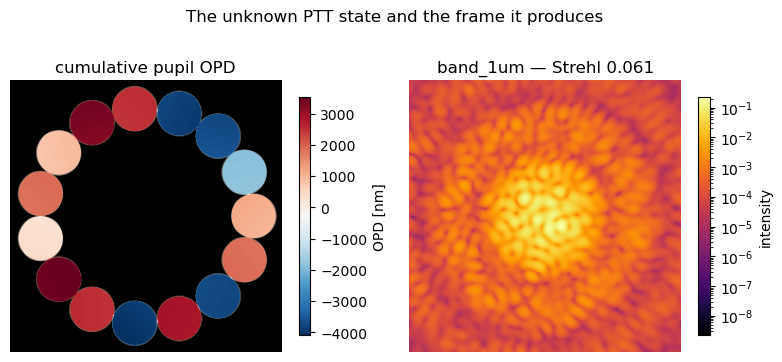

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from telescope_sim.config.loader import build
from telescope_sim.config.schema import SimConfig
from telescope_sim.helpers.diagnostics import plot_opd_and_psfs

# The elf_15seg geometry with a single broadband band: 1 um
# central wavelength, 10% fractional bandwidth, 13 samples.
config = {
    "backend": "jax",
    "pupil": {"resolution": 256, "extent": 3.1563881637},
    "aperture": {
        "type": "segmented_circular", "layout": "elf",
        "n_segments": 15, "ring_radius": 1.25,
        "segment_diameter": 0.5197792270, "supersample": 16,
    },
    "correctors": {
        "segments": {
            "type": "segmented_ptt",
            "piston_scale": 1.0e-6, "tip_tilt_scale": 1.0e-6,
            "wavefront_role": "actuate",
            "target_strategy": "actuators", "target": True,
        }
    },
    "corrector_chain": ["segments"],
    "focal_planes": {
        "band_1um": {
            "type": "angular", "central_lam": 1.0e-6,
            "focal_extent": 2.0, "focal_res": 160,
            "fractional_bandwidth": 0.10, "num_samples": 13,
        }
    },
    "outputs": {
        "psf": {"tap": {"type": "intensity", "focal_planes": ["band_1um"]},
                "post_processing": [{"type": "max_intensity_norm"}]}
    },
}
sim = build(SimConfig.model_validate(config))

# The unknown state to recover: random piston/tip/tilt on all 15
# segments. Pistons span ±2 um of surface = ±4 um of OPD —
# up to ±4 whole waves at 1 um, far beyond any monochromatic
# capture range.
PISTON_RANGE = 2.0
rng = np.random.default_rng(0)
ptt_true = np.zeros((15, 3))
ptt_true[:, 0] = rng.uniform(-PISTON_RANGE, PISTON_RANGE, 15)
ptt_true[:, 1:] = rng.uniform(-0.2, 0.2, (15, 2))

out = sim.sample({"segments": ptt_true}, meas_strehl=True, meas_pupil_opd=True)
plot_opd_and_psfs(sim, out,
                  suptitle="The unknown PTT state and the frame it produces")
plt.show()


## Exporting the forward model

`sim.forward_fn()` returns the telescope as a pure callable — actuations in, per-filter focal intensities out, `jit`/`vmap`/`grad`-compatible. To use it the dLux way, wrap it in a `zodiax.Base` module whose array fields are pytree leaves: the PTT state becomes a *parameter of the model*, and everything zodiax/equinox offer (path-based `get`/`set`, filtered transforms, optax integration) applies to the telescope like any other dLux model.

`model()` follows the dLux convention of returning the observation — here the flux-normalized broadband frame. The measurement we will fit against is the model evaluated at the true state, detected at a realistic photon budget (10⁷ photons of shot noise).

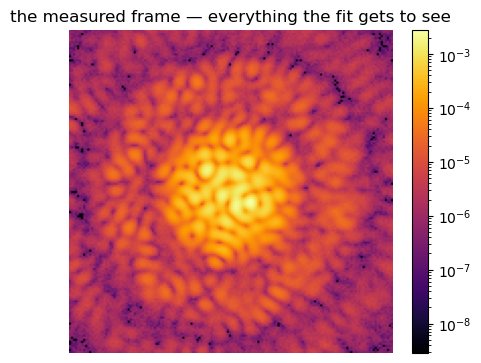

In [2]:
import equinox as eqx
import jax
import jax.numpy as jnp
import optax
import zodiax as zdx


class PTTModel(zdx.Base):
    ptt: jax.Array   # (15, 3) piston/tip/tilt per segment — the free parameters
    forward: object  # the telescope's pure forward model (static)

    def __init__(self, sim, ptt=None):
        self.forward = sim.forward_fn()
        self.ptt = jnp.zeros((15, 3)) if ptt is None else jnp.asarray(ptt, float)

    def model(self):
        images = self.forward({"segments": self.ptt})
        return {name: img / img.sum() for name, img in images.items()}


model = PTTModel(sim)  # parameters at zero: the starting guess

# The single measured broadband frame: the true state rendered and
# detected at a realistic photon budget - 1e7 photons of shot noise.
noise_key = jax.random.PRNGKey(7)


def measure(images):
    counts = {name: jax.random.poisson(jax.random.fold_in(noise_key, i), img * 1e7)
              for i, (name, img) in enumerate(sorted(images.items()))}
    return {name: c / c.sum() for name, c in counts.items()}


data = measure(PTTModel(sim, ptt_true).model())

fig, ax = plt.subplots(figsize=(5.2, 4.2))
img = np.asarray(data["band_1um"])
peak = float(img.max())
im = ax.imshow(np.maximum(img, peak * 1e-6), cmap="inferno",
               norm=LogNorm(vmin=peak * 1e-6, vmax=peak))
ax.set_title("the measured frame — everything the fit gets to see")
ax.set_axis_off()
fig.colorbar(im, ax=ax, fraction=0.046)
plt.show()


## Retrieval: multi-start descent + integer wrap resolution

The loss compares amplitudes (square roots of intensities) — better-behaved gradients than intensity MSE across a PSF's dynamic range. The landscape is not convex: its minima repeat along each segment's piston at whole-wave offsets (the *wrap comb*), with the true state deepest thanks to the bandwidth. A recipe that handles this reliably:

1. **Multi-start descent** — run many optimizations from random starting points *simultaneously*: batch the parameter leaf to `(N, 15, 3)` and sum the per-start losses. Gradients don't couple across starts and adam is elementwise, so one ordinary training loop runs N independent descents on-device.
2. **Integer wrap resolution** — descents converge quickly but may land a whole wave off on some pistons. Test comb hops per segment in one batched evaluation and greedily accept improvements; the broadband envelope makes hops toward the true state improve the loss.
3. **Re-polish** the winner with a short low-learning-rate descent.

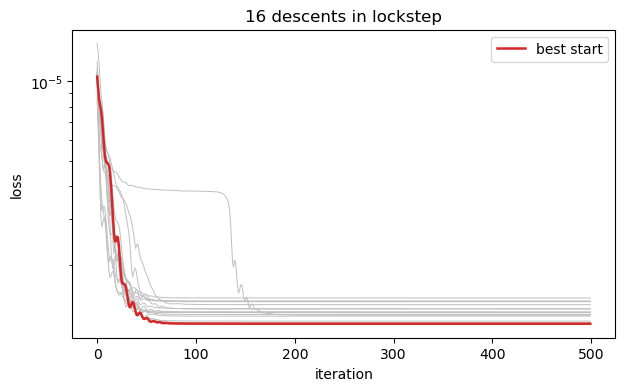

In [3]:
def one_loss(ptt, model, data):
    images = model.set("ptt", ptt).model()
    return sum(jnp.mean((jnp.sqrt(images[k]) - jnp.sqrt(data[k])) ** 2)
               for k in data)


@eqx.filter_jit
@eqx.filter_value_and_grad(has_aux=True)
def loss_fn(params, model, data):
    per_start = jax.vmap(one_loss, in_axes=(0, None, None))(
        params["ptt"], model, data)
    return per_start.sum(), per_start


N_STARTS, ITERS = 16, 500
start_rng = np.random.default_rng(99)
starts = np.zeros((N_STARTS, 15, 3))
starts[1:, :, 0] = start_rng.uniform(-PISTON_RANGE, PISTON_RANGE,
                                     (N_STARTS - 1, 15))
starts[1:, :, 1:] = start_rng.uniform(-0.2, 0.2, (N_STARTS - 1, 15, 2))

params = {"ptt": jnp.asarray(starts)}
optim, state = zdx.map_optimisers(
    params, {"ptt": optax.adam(optax.cosine_decay_schedule(3e-2, ITERS))})

history = []
for _ in range(ITERS):
    (_, per_start), grads = loss_fn(params, model, data)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    history.append(np.asarray(per_start))
history = np.array(history)

plt.figure(figsize=(7, 4))
plt.semilogy(history, color="0.75", lw=0.7)
plt.semilogy(history[:, history[-1].argmin()], color="C3", lw=1.8,
             label="best start")
plt.xlabel("iteration")
plt.ylabel("loss")
plt.legend()
plt.title(f"{N_STARTS} descents in lockstep")
plt.show()


In [4]:
batched_loss = eqx.filter_jit(jax.vmap(one_loss, in_axes=(0, None, None)))

# Piston comb offsets, in caller units (um of surface): 0.5 um of
# surface is one wave of OPD at 1 um. Offsets up to four waves let
# greedy hops compose their way out of the deepest wraps.
DELTAS = [s * c for c in (0.5, 1.0, 1.5, 2.0) for s in (1.0, -1.0)]


def wrap_resolve(ptt, base):
    """Greedy per-segment piston comb hops, one batched eval per step."""
    hops = 0
    for _ in range(60):
        cands = np.repeat(ptt[None], 15 * len(DELTAS), axis=0)
        for i in range(15):
            for j, d in enumerate(DELTAS):
                cands[i * len(DELTAS) + j, i, 0] += d
        losses = np.asarray(batched_loss(jnp.asarray(cands), model, data))
        k = int(np.argmin(losses))
        if not losses[k] < base * 0.999:
            return ptt, base, hops
        ptt, base = cands[k], float(losses[k])
        hops += 1
    return ptt, base, hops


final = history[-1]
best_ptt, best_loss = None, np.inf
for idx in np.argsort(final)[:2]:
    hopped, loss_i, hops = wrap_resolve(
        np.array(params["ptt"][idx], dtype=float), float(final[idx]))
    print(f"start {idx}: {hops} wrap hops, loss {final[idx]:.2e} -> {loss_i:.2e}")
    if loss_i < best_loss:
        best_ptt, best_loss = hopped, loss_i

polish = {"ptt": jnp.asarray(best_ptt[None])}
optim, state = zdx.map_optimisers(polish, {"ptt": optax.adam(3e-3)})
for _ in range(150):
    (loss, _), grads = loss_fn(polish, model, data)
    updates, state = optim.update(grads, state)
    polish = optax.apply_updates(polish, updates)
ptt_rec = np.asarray(polish["ptt"][0], dtype=float)
print(f"re-polished loss: {float(loss):.2e}")


start 3: 20 wrap hops, loss 1.20e-06 -> 1.15e-07


start 0: 16 wrap hops, loss 1.21e-06 -> 1.84e-07


re-polished loss: 2.85e-08


## The recovered state, in actuator space

Global piston is unobservable — an equal piston on every segment moves no fringes — so both states are compared with their mean piston removed.

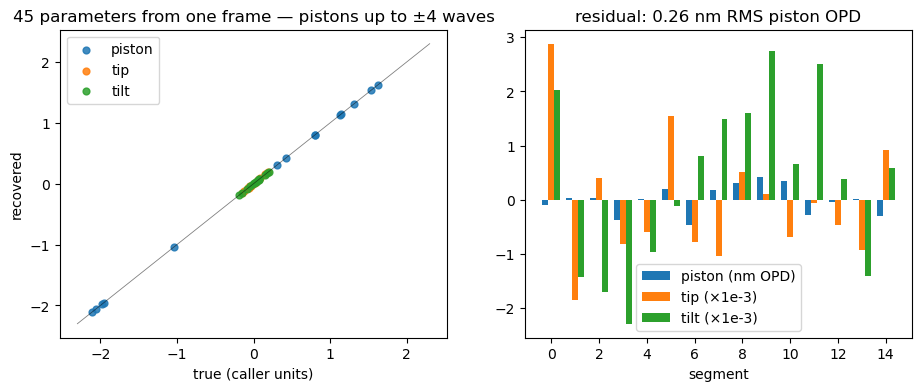

In [5]:
t = ptt_true.copy()
h = ptt_rec.copy()
t[:, 0] -= t[:, 0].mean()
h[:, 0] -= h[:, 0].mean()
res = h - t

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for k, (label, color) in enumerate(zip(["piston", "tip", "tilt"],
                                       ["C0", "C1", "C2"])):
    axes[0].scatter(t[:, k], h[:, k], s=24, color=color, label=label,
                    alpha=0.85)
lim = PISTON_RANGE * 1.15
axes[0].plot([-lim, lim], [-lim, lim], "k-", lw=0.6, alpha=0.5)
axes[0].set_xlabel("true (caller units)")
axes[0].set_ylabel("recovered")
axes[0].set_title("45 parameters from one frame — pistons up to ±4 waves")
axes[0].legend()

x = np.arange(15)
axes[1].bar(x - 0.25, res[:, 0] * 2e3, 0.25, label="piston (nm OPD)")
axes[1].bar(x, res[:, 1] * 1e3, 0.25, label="tip (×1e-3)")
axes[1].bar(x + 0.25, res[:, 2] * 1e3, 0.25, label="tilt (×1e-3)")
axes[1].set_xlabel("segment")
axes[1].set_title(
    f"residual: {np.sqrt(np.mean(res[:, 0] ** 2)) * 2e3:.2f} nm RMS piston OPD")
axes[1].legend()
plt.show()


## Closing the loop

Apply the recovered state, negated, on top of the (still unknown) true state — exactly what a controller would command — and the telescope returns to the diffraction limit.

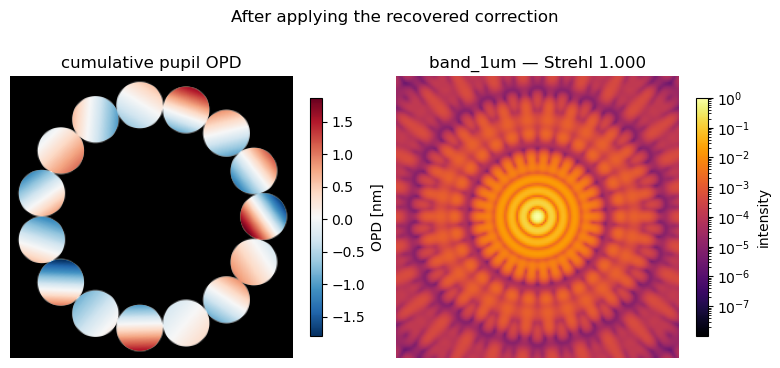

strehls: {'band_1um': 1.0003}


In [6]:
corrected = sim.sample({"segments": t - h}, meas_strehl=True,
                       meas_pupil_opd=True)
plot_opd_and_psfs(sim, corrected,
                  suptitle="After applying the recovered correction")
plt.show()
print("strehls:", {k: round(float(v), 4)
                   for k, v in corrected['strehls'].items()})


## Notes

- The same pattern works for **any** config and corrector kind: `forward_fn` probes correctors numerically, so a Zernike DM or an `actuator_grid` DM exports identically — nothing here is specific to the segmented PTT corrector.
- The model is an ordinary pytree. Swap adam for any optax optimiser, stage learning rates per parameter with `zdx.map_optimisers`, or hand the same loss to a JAX-native sampler (numpyro, blackjax) for posteriors instead of point estimates.
- Runtime scales with starts × iterations, but every start shares one jitted program — widening the search is cheap, especially on accelerators.